# Survival analysis in clinical and public health research



**Authors:** Renato Carneiro de Freitas Chaves, Tiago Mendonça dos Santos, Thiago Domingos Corrêa

# 1) Purpose

This notebook provides a clear, step-by-step introduction to survival analysis.
The analysis addresses five questions:

1. What is the estimated probability of remaining alive over time?
2. Do the survival functions differ between the two groups?
3. What is the intervention-to-control hazard ratio?
4. Does adjustment for a prespecified baseline severity measure materially change the estimated association?
5. Is the proportional-hazards assumption reasonable?

## 2) Required Libraries

This notebook uses standard scientific Python libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.stats import norm, chi2
from statsmodels.nonparametric.smoothers_lowess import lowess
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, proportional_hazard_test
from lifelines.utils import median_survival_times

pd.set_option("display.precision", 4)

RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xf. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.

## 3) Data Import (Excel)

This guide uses the Excel file **`data.xlsx`** with a sheet named **`Data`**.

- If `data.xlsx` is in the same folder as this notebook, you can keep the path as `"data.xlsx"`.
- Otherwise, replace with the full path to your file.

In [2]:
# Update the path if needed
excel_path = "data.xlsx"
sheet_name = "Data"

data = pd.read_excel(excel_path, sheet_name=sheet_name)

# Quick inspection
data.head(), data.shape

(   patient  group  center follow_up_start follow_up_end  follow_up_days  \
 0        1      1       1      2022-06-08    2023-10-10             489   
 1        2      1       1      2022-06-28    2023-08-24             422   
 2        3      1       1      2022-01-14    2022-11-02             292   
 3        4      1       1      2022-06-19    2024-04-05             656   
 4        5      1       1      2022-02-19    2023-01-15             330   
 
    follow_up_years  age  platelet  hemoglobin  ...  smoking  \
 0           1.3388   19       229        15.3  ...        0   
 1           1.1554   24       221        14.8  ...        0   
 2           0.7995   25       219        14.4  ...        0   
 3           1.7960   26       217        14.3  ...        0   
 4           0.9035   27       214        13.8  ...        0   
 
    chronic_kidney_disease  cancer  stroke  saps_3  vasopressor  \
 0                       0       0       0       5            0   
 1                    

# 4) Variable definitions and data inspection

Before conducting statistical analysis, the investigator should inspect the dataset structure, confirm the variable names, and review the first observations.

The main variables used in this report are:

- `follow_up_days`: observed time from the defined baseline to death or censoring, measured in days.
- `event`: event indicator, coded as 1 for death during follow-up and 0 for right censoring.
- `group`: allocation group, coded as 0 for control and 1 for intervention.
- `saps_3`: Simplified Acute Physiology Score 3 at ICU admission.
- `saps_3_10`: SAPS 3 divided by 10, so its Cox-model hazard ratio corresponds to a 10-point increase.
- `outcome`: vital status at hospital discharge, coded as 0 for alive and 1 for dead. This variable is not used as the survival-event indicator because it refers to a different observation window.

The investigator should confirm the dimensions, variable names, coding, and first observations before fitting any model.

In [3]:
# Number of rows and columns.
print("Dataset dimensions:", data.shape)

# Variable names.
print("\nVariable names:")
print(list(data.columns))

# First six records.
data.head(6)

Dataset dimensions: (50, 24)

Variable names:
['patient', 'group', 'center', 'follow_up_start', 'follow_up_end', 'follow_up_days', 'follow_up_years', 'age', 'platelet', 'hemoglobin', 'creatinine', 'hypertension', 'diabetes', 'heart_failure', 'smoking', 'chronic_kidney_disease', 'cancer', 'stroke', 'saps_3', 'vasopressor', 'mechanical_ventilation', 'fluid_balance', 'outcome', 'event']


,patient,group,center,follow_up_start,follow_up_end,follow_up_days,follow_up_years,age,platelet,hemoglobin,...,smoking,chronic_kidney_disease,cancer,stroke,saps_3,vasopressor,mechanical_ventilation,fluid_balance,outcome,event
0,1,1,1,2022-06-08,2023-10-10,489,1.3388,19,229,15.3,...,0,0,0,0,5,0,0,-956,0,0
1,2,1,1,2022-06-28,2023-08-24,422,1.1554,24,221,14.8,...,0,0,0,0,8,0,0,-3600,0,0
2,3,1,1,2022-01-14,2022-11-02,292,0.7995,25,219,14.4,...,0,0,0,0,10,0,0,-820,0,0
3,4,1,1,2022-06-19,2024-04-05,656,1.7960,26,217,14.3,...,0,0,0,0,18,0,0,-660,0,0
4,5,1,1,2022-02-19,2023-01-15,330,0.9035,27,214,13.8,...,0,1,1,0,19,1,0,-600,0,0
5,6,1,1,2022-04-28,2023-04-08,345,0.9446,27,213,13.1,...,1,1,1,0,24,1,1,-400,1,1


# 5) Basic data preparation

The code below confirms that the required variables exist, converts them to numeric form, and verifies the survival coding.

The primary unadjusted analyses require only follow-up time, event status, and group. The adjusted model additionally requires SAPS 3. Separate analytic datasets prevent missing covariate values from unnecessarily excluding participants from the Kaplan–Meier, log-rank, or unadjusted Cox analyses.

In [4]:
required_variables = ["follow_up_days", "event", "group", "saps_3", "outcome"]

# Work on a copy so that the imported dataset remains unchanged.
analysis_data = data.copy()

# Convert only variables used in the analysis. Values that cannot be converted
# become missing, which mirrors the practical effect of coercion in R.
for variable in required_variables:
    analysis_data[variable] = pd.to_numeric(analysis_data[variable], errors="coerce")

survival_data = analysis_data.dropna(
    subset=["follow_up_days", "event", "group"]
).copy()

adjusted_data = analysis_data.dropna(
    subset=["follow_up_days", "event", "group", "saps_3"]
).copy()

survival_data["event"] = survival_data["event"].astype(int)
adjusted_data["event"] = adjusted_data["event"].astype(int)

group_labels = {0: "Control", 1: "Intervention"}

survival_data["group"] = pd.Categorical(
    survival_data["group"].map(group_labels),
    categories=["Control", "Intervention"],
    ordered=True,
)

adjusted_data["group"] = pd.Categorical(
    adjusted_data["group"].map(group_labels),
    categories=["Control", "Intervention"],
    ordered=True,
)

# Express SAPS 3 per 10-point increase for easier interpretation.
adjusted_data["saps_3_10"] = adjusted_data["saps_3"] / 10.0

print(f"Unadjusted analytic sample: {len(survival_data)} participants")
print(f"Adjusted analytic sample: {len(adjusted_data)} participants")

Unadjusted analytic sample: 50 participants
Adjusted analytic sample: 50 participants


# 6) Descriptive summary

Observed time is the minimum of event time and censoring time. It should not be interpreted as the distribution of potential follow-up. Median potential follow-up is estimated later with the reverse Kaplan–Meier method.

In [5]:
group_summary = (
    survival_data.groupby("group", observed=False)
    .agg(
        Participants=("event", "size"),
        Deaths=("event", "sum"),
        Median_observed_time_days=("follow_up_days", "median"),
    )
    .reset_index()
    .rename(columns={"group": "Group"})
)

group_summary["Censored"] = (
    group_summary["Participants"] - group_summary["Deaths"]
)

group_summary = group_summary[
    ["Group", "Participants", "Deaths", "Censored", "Median_observed_time_days"]
]

print("Descriptive summary by allocation group")
display(group_summary.round(1))

Descriptive summary by allocation group


,Group,Participants,Deaths,Censored,Median_observed_time_days
0,Control,25,20,5,219.0
1,Intervention,25,13,12,335.0


# 7) Kaplan–Meier estimation, numbers at risk, milestone survival, absolute survival difference, and median survival


In [6]:
survival_object_preview = survival_data[
    ["follow_up_days", "event"]
].rename(columns={"follow_up_days": "time"})

display(survival_object_preview.head())

,time,event
0,489,0
1,422,0
2,292,0
3,656,0
4,330,0


## 7.1) Overall Kaplan–Meier curve

The confidence intervals produced by `KaplanMeierFitter` use Greenwood variance with the exponential Greenwood, or log–log, transformation.

Overall Kaplan–Meier event table


,removed,observed,censored,entrance,at_risk
event_at,,,,,
0.0,0,0,0,50,50
33.0,1,1,0,0,50
45.0,1,1,0,0,49
54.0,1,1,0,0,48
68.0,1,1,0,0,47
80.0,1,1,0,0,46
96.0,1,1,0,0,45
98.0,1,1,0,0,44
103.0,1,1,0,0,43


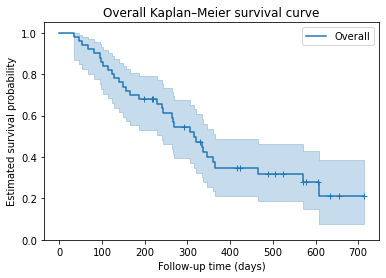

In [7]:
km_overall = KaplanMeierFitter(alpha=0.05, label="Overall")
km_overall.fit(
    durations=survival_data["follow_up_days"],
    event_observed=survival_data["event"],
)

print("Overall Kaplan–Meier event table")
display(km_overall.event_table.head(10))

ax = km_overall.plot_survival_function(
    ci_show=True,
    show_censors=True,
    censor_styles={"marker": "+", "ms": 6},
)
ax.set(
    xlabel="Follow-up time (days)",
    ylabel="Estimated survival probability",
    title="Overall Kaplan–Meier survival curve",
    ylim=(0, 1.05),
)
plt.show()

## 7.2) Kaplan–Meier curves by group

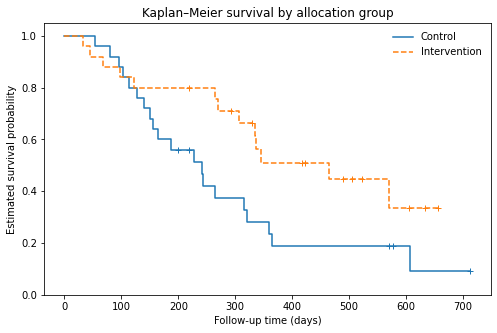

In [8]:
km_by_group = {}
line_styles = {"Control": "-", "Intervention": "--"}

fig, ax = plt.subplots(figsize=(8, 5))

for group_name in ["Control", "Intervention"]:
    group_mask = survival_data["group"] == group_name
    fitter = KaplanMeierFitter(alpha=0.05, label=group_name)
    fitter.fit(
        durations=survival_data.loc[group_mask, "follow_up_days"],
        event_observed=survival_data.loc[group_mask, "event"],
    )
    km_by_group[group_name] = fitter
    fitter.plot_survival_function(
        ax=ax,
        ci_show=False,
        show_censors=True,
        linestyle=line_styles[group_name],
        censor_styles={"marker": "+", "ms": 6},
    )

ax.set(
    xlabel="Follow-up time (days)",
    ylabel="Estimated survival probability",
    title="Kaplan–Meier survival by allocation group",
    ylim=(0, 1.05),
)
ax.legend(frameon=False)
plt.show()

## 7.3) Numbers at risk and milestone survival

The number at risk at time $t$ is calculated immediately before $t$, so participants with an event or censoring time equal to $t$ remain in the risk set at that instant.

In [9]:
def km_confidence_interval_at_time(kmf, time):
    """Return the step-function confidence limits at a specified time."""
    ci = kmf.confidence_interval_survival_function_
    eligible_times = ci.index[ci.index <= time]

    if len(eligible_times) == 0:
        return 1.0, 1.0

    row = ci.loc[eligible_times[-1]]
    return float(row.iloc[0]), float(row.iloc[1])


def greenwood_standard_error(kmf, time):
    """Calculate Greenwood's standard error for the KM survival estimate."""
    event_table = kmf.event_table.loc[kmf.event_table.index <= time]
    observed = event_table["observed"].to_numpy(dtype=float)
    at_risk = event_table["at_risk"].to_numpy(dtype=float)

    valid = (observed > 0) & (at_risk > observed)
    if np.any((observed > 0) & (at_risk == observed)):
        return np.nan

    greenwood_sum = np.sum(
        observed[valid] / (at_risk[valid] * (at_risk[valid] - observed[valid]))
    )
    survival = float(kmf.predict(time))
    return survival * np.sqrt(greenwood_sum)


common_follow_up_limit = (
    survival_data.groupby("group", observed=False)["follow_up_days"]
    .max()
    .min()
)

candidate_times = np.array([0, 180, 365, 540], dtype=float)
risk_times = candidate_times[candidate_times <= common_follow_up_limit]

risk_rows = []
for group_name, kmf in km_by_group.items():
    group_mask = survival_data["group"] == group_name
    group_durations = survival_data.loc[group_mask, "follow_up_days"]

    for time in risk_times:
        ci_lower, ci_upper = km_confidence_interval_at_time(kmf, time)
        risk_rows.append(
            {
                "Group": group_name,
                "Time_days": time,
                "Number_at_risk": int((group_durations >= time).sum()),
                "Survival_probability": float(kmf.predict(time)),
                "CI_lower": ci_lower,
                "CI_upper": ci_upper,
            }
        )

risk_table = pd.DataFrame(risk_rows)

print("Numbers at risk and Kaplan–Meier survival estimates")
display(risk_table.round(3))

Numbers at risk and Kaplan–Meier survival estimates


,Group,Time_days,Number_at_risk,Survival_probability,CI_lower,CI_upper
0,Control,0.0,25,1.000,1.000,1.000
1,Control,180.0,15,0.600,0.384,0.761
2,Control,365.0,4,0.187,0.059,0.369
3,Control,540.0,4,0.187,0.059,0.369
4,Intervention,0.0,25,1.000,1.000,1.000
5,Intervention,180.0,20,0.800,0.584,0.911
6,Intervention,365.0,10,0.511,0.288,0.696
7,Intervention,540.0,4,0.447,0.227,0.645


## 7.4) Absolute survival difference at a prespecified time


In [10]:
milestone_day = 365.0

if milestone_day > common_follow_up_limit:
    raise ValueError(
        "The selected milestone exceeds the observed follow-up range of at least one group."
    )

milestone_rows = []
for group_name, kmf in km_by_group.items():
    ci_lower, ci_upper = km_confidence_interval_at_time(kmf, milestone_day)
    milestone_rows.append(
        {
            "Group": group_name,
            "Time_days": milestone_day,
            "Survival_probability": float(kmf.predict(milestone_day)),
            "Standard_error": greenwood_standard_error(kmf, milestone_day),
            "CI_lower": ci_lower,
            "CI_upper": ci_upper,
        }
    )

milestone_table = pd.DataFrame(milestone_rows).set_index("Group")

control_survival_365 = milestone_table.loc["Control", "Survival_probability"]
intervention_survival_365 = milestone_table.loc[
    "Intervention", "Survival_probability"
]

survival_difference_365 = intervention_survival_365 - control_survival_365

survival_difference_se = np.sqrt(
    milestone_table.loc["Intervention", "Standard_error"] ** 2
    + milestone_table.loc["Control", "Standard_error"] ** 2
)

survival_difference_ci = survival_difference_365 + np.array([-1, 1]) * norm.ppf(
    0.975
) * survival_difference_se

# A difference between two probabilities must lie between -1 and 1.
survival_difference_ci = np.clip(survival_difference_ci, -1, 1)

print("Estimated 365-day survival by allocation group")
display(milestone_table.reset_index().round(3))

print(f"Absolute 365-day survival difference: {survival_difference_365:.3f}")
print(
    "Approximate 95% confidence interval: "
    f"{survival_difference_ci[0]:.3f} to {survival_difference_ci[1]:.3f}"
)

Estimated 365-day survival by allocation group


,Group,Time_days,Survival_probability,Standard_error,CI_lower,CI_upper
0,Control,365.0,0.187,0.083,0.059,0.369
1,Intervention,365.0,0.511,0.108,0.288,0.696


Absolute 365-day survival difference: 0.324
Approximate 95% confidence interval: 0.057 to 0.591


## 7.5) Median survival

Median survival is the earliest time at which the Kaplan–Meier estimate is 0.50 or lower. It is not estimable if the curve does not reach 0.50 during observed follow-up.

In [11]:
median_survival_rows = []

for group_name, kmf in km_by_group.items():
    median_ci = median_survival_times(kmf.confidence_interval_survival_function_)

    median_survival_rows.append(
        {
            "Group": group_name,
            "Median_days": float(kmf.median_survival_time_),
            "CI_lower": float(median_ci.iloc[0, 0]),
            "CI_upper": float(median_ci.iloc[0, 1]),
        }
    )

median_survival_table = pd.DataFrame(median_survival_rows)

print("Median survival by allocation group")
display(median_survival_table.round(1))

Median survival by allocation group


,Group,Median_days,CI_lower,CI_upper
0,Control,241.0,150.0,320.0
1,Intervention,465.0,269.0,inf


# 8) Log-rank test

The log-rank test compares observed and expected deaths over the full follow-up period. It provides a global unadjusted comparison but does not estimate an effect size.

For two groups, the test statistic is compared with a chi-square distribution with one degree of freedom.

In [12]:
control_mask = survival_data["group"] == "Control"
intervention_mask = survival_data["group"] == "Intervention"

logrank_result = logrank_test(
    durations_A=survival_data.loc[control_mask, "follow_up_days"],
    durations_B=survival_data.loc[intervention_mask, "follow_up_days"],
    event_observed_A=survival_data.loc[control_mask, "event"],
    event_observed_B=survival_data.loc[intervention_mask, "event"],
)

logrank_chi_square = float(logrank_result.test_statistic)
logrank_df = 1
logrank_p_value = float(logrank_result.p_value)

print(f"Chi-square statistic: {logrank_chi_square:.3f}")
print(f"Degrees of freedom: {logrank_df}")
print(f"P value: {logrank_p_value:.6f}")

Chi-square statistic: 4.427
Degrees of freedom: 1
P value: 0.035373


# 9) Unadjusted Cox proportional-hazards model
Under proportional hazards, a hazard ratio below 1 indicates a lower instantaneous death hazard in the intervention group than in the control group among participants who remain alive at each time. It is not a fixed-time risk ratio or a ratio of survival probabilities.

In [13]:
cox_unadjusted_data = survival_data[
    ["follow_up_days", "event", "group"]
].copy()
cox_unadjusted_data["group_intervention"] = (
    cox_unadjusted_data["group"] == "Intervention"
).astype(int)
cox_unadjusted_data = cox_unadjusted_data.drop(columns="group").reset_index(drop=True)

cox_unadjusted = CoxPHFitter()
cox_unadjusted.fit(
    cox_unadjusted_data,
    duration_col="follow_up_days",
    event_col="event",
    formula="group_intervention",
)

cox_unadjusted.print_summary()

unadjusted_row = cox_unadjusted.summary.loc["group_intervention"]
unadjusted_hr = float(unadjusted_row["exp(coef)"])
unadjusted_ci = np.array(
    [
        unadjusted_row["exp(coef) lower 95%"],
        unadjusted_row["exp(coef) upper 95%"],
    ],
    dtype=float,
)
unadjusted_p_value = float(unadjusted_row["p"])

unadjusted_cox_table = pd.DataFrame(
    {
        "Comparison": ["Intervention vs Control"],
        "Hazard_ratio": [unadjusted_hr],
        "CI_lower": [unadjusted_ci[0]],
        "CI_upper": [unadjusted_ci[1]],
        "P_value": [unadjusted_p_value],
    }
)

print("Unadjusted Cox proportional-hazards model")
display(unadjusted_cox_table.round(3))

AttributeError: The '.style' accessor requires jinja2

<lifelines.CoxPHFitter: fitted with 50 total observations, 17 right-censored observations>
             duration col = 'follow_up_days'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 50
number of events observed = 33
   partial log-likelihood = -106.96
         time fit was run = 2026-06-18 13:44:25 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
group_intervention -0.74      0.48      0.36           -1.45           -0.04                0.23                0.96

                    cmp to     z    p  -log2(p)
covariate                                      
group_intervention    0.00 -2.06 0.04      4.67
---
Concordance = 0.59
Partial AIC = 215.91
log-likelihood ratio test = 4.37 on 1 df
-log2(p) of ll-ratio test = 4.77

Unadjusted Cox proportional-hazards model


,Comparison,Hazard_ratio,CI_lower,CI_upper,P_value
0,Intervention vs Control,0.476,0.235,0.965,0.039


## 9.1) Parsimonious adjusted Cox model

To preserve stability and clarity in this small educational dataset, the adjusted model includes allocation group and one prespecified baseline severity measure, SAPS 3. The SAPS 3 coefficient is scaled to a 10-point increase. The adjusted group coefficient is conditional on SAPS 3 and should not automatically be interpreted as causal.

In [14]:
cox_adjusted_data = adjusted_data[
    ["follow_up_days", "event", "group", "saps_3_10"]
].copy()
cox_adjusted_data["group_intervention"] = (
    cox_adjusted_data["group"] == "Intervention"
).astype(int)
cox_adjusted_data = cox_adjusted_data.drop(columns="group").reset_index(drop=True)

cox_adjusted = CoxPHFitter()
cox_adjusted.fit(
    cox_adjusted_data,
    duration_col="follow_up_days",
    event_col="event",
    formula="group_intervention + saps_3_10",
)

cox_adjusted.print_summary()

adjusted_summary = cox_adjusted.summary.copy()
adjusted_cox_table = pd.DataFrame(
    {
        "Term": [
            "Intervention vs Control",
            "SAPS 3, per 10-point increase",
        ],
        "Hazard_ratio": [
            adjusted_summary.loc["group_intervention", "exp(coef)"],
            adjusted_summary.loc["saps_3_10", "exp(coef)"],
        ],
        "CI_lower": [
            adjusted_summary.loc["group_intervention", "exp(coef) lower 95%"],
            adjusted_summary.loc["saps_3_10", "exp(coef) lower 95%"],
        ],
        "CI_upper": [
            adjusted_summary.loc["group_intervention", "exp(coef) upper 95%"],
            adjusted_summary.loc["saps_3_10", "exp(coef) upper 95%"],
        ],
        "P_value": [
            adjusted_summary.loc["group_intervention", "p"],
            adjusted_summary.loc["saps_3_10", "p"],
        ],
    }
)

print("Parsimonious adjusted Cox proportional-hazards model")
display(adjusted_cox_table.round(3))

AttributeError: The '.style' accessor requires jinja2

<lifelines.CoxPHFitter: fitted with 50 total observations, 17 right-censored observations>
             duration col = 'follow_up_days'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 50
number of events observed = 33
   partial log-likelihood = -104.64
         time fit was run = 2026-06-18 13:44:27 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
group_intervention  0.22      1.25      0.57           -0.90            1.35                0.41                3.84
saps_3_10           0.35      1.41      0.16            0.03            0.66                1.03                1.94

                    cmp to    z    p  -log2(p)
covariate                                     
group_intervention    0.00 0.39 0.70      0.52
saps_3_10             0.00 2.14 0.03      4.95
---
Concordance = 0.62
Partial AIC = 213.28
log-likelihood ratio test = 9.00 on 2 df
-log2(p) of ll-ratio test = 6.49

Parsimonious adjusted Cox proportional-hazards model


,Term,Hazard_ratio,CI_lower,CI_upper,P_value
0,Intervention vs Control,1.251,0.407,3.842,0.696
1,"SAPS 3, per 10-point increase",1.414,1.030,1.940,0.032


## 9.2) Proportional-hazards assessment

A systematic relationship between scaled Schoenfeld residuals and time suggests nonproportional hazards. A nonsignificant test does not prove proportional hazards, particularly in a small sample. Covariate-specific tests should be interpreted together with the residual plot and the Kaplan–Meier curves.

The `lifelines` proportional-hazards test with `time_transform="km"` follows the same broad Schoenfeld-residual logic as `survival::cox.zph(transform="km")`; however, its approximation may not reproduce the exact numerical results of recent versions of R's `survival` package. `lifelines` reports covariate-specific tests but not the covariance-adjusted global test reported by `cox.zph`. The optional omnibus statistic below is the sum of the individual one-degree-of-freedom statistics and should be labeled as an approximate summary, not as an exact replacement for the R global test.

Covariate-specific proportional-hazards tests


,Chi_square,P_value,Minus_log2_P
group_intervention,1.0872,0.2971,1.7510
saps_3_10,2.3819,0.1228,3.0262


Allocation-group PH-test P value: 0.2971
Approximate omnibus PH-test: chi-square = 3.469, df = 2, P = 0.1765


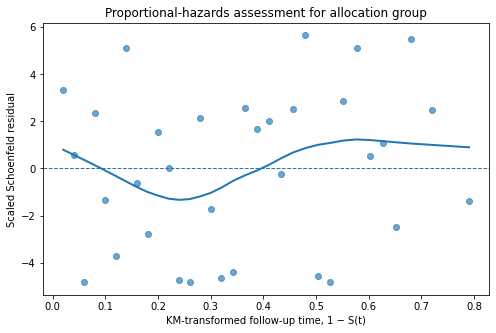

In [15]:
ph_test = proportional_hazard_test(
    cox_adjusted,
    cox_adjusted_data,
    time_transform="km",
)

ph_table = ph_test.summary.rename(
    columns={
        "test_statistic": "Chi_square",
        "p": "P_value",
        "-log2(p)": "Minus_log2_P",
    }
)

print("Covariate-specific proportional-hazards tests")
display(ph_table.round(4))

ph_group_p = float(ph_test.summary.loc["group_intervention", "p"])

# Approximate omnibus summary; this is not identical to the covariance-adjusted
# GLOBAL test from current versions of survival::cox.zph.
ph_global_chi_square_approx = float(ph_test.summary["test_statistic"].sum())
ph_global_df_approx = int(len(ph_test.summary))
ph_global_p_approx = float(
    chi2.sf(ph_global_chi_square_approx, df=ph_global_df_approx)
)

print(f"Allocation-group PH-test P value: {ph_group_p:.4f}")
print(
    "Approximate omnibus PH-test: "
    f"chi-square = {ph_global_chi_square_approx:.3f}, "
    f"df = {ph_global_df_approx}, P = {ph_global_p_approx:.4f}"
)

# Scaled Schoenfeld residual plot for the allocation-group coefficient.
scaled_schoenfeld = cox_adjusted.compute_residuals(
    cox_adjusted_data,
    kind="scaled_schoenfeld",
)

event_times = cox_adjusted_data.loc[
    scaled_schoenfeld.index, "follow_up_days"
].to_numpy(dtype=float)

overall_adjusted_km = KaplanMeierFitter().fit(
    cox_adjusted_data["follow_up_days"],
    event_observed=cox_adjusted_data["event"],
)
km_transformed_time = 1.0 - overall_adjusted_km.predict(event_times).to_numpy()

group_residuals = scaled_schoenfeld["group_intervention"].to_numpy(dtype=float)

smoothed = lowess(
    endog=group_residuals,
    exog=km_transformed_time,
    frac=0.60,
    return_sorted=True,
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(km_transformed_time, group_residuals, alpha=0.65)
ax.plot(smoothed[:, 0], smoothed[:, 1], linewidth=2)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set(
    xlabel="KM-transformed follow-up time, 1 − S(t)",
    ylabel="Scaled Schoenfeld residual",
    title="Proportional-hazards assessment for allocation group",
)
plt.show()

# 10) Follow-up estimated by the reverse Kaplan–Meier method

The reverse Kaplan–Meier method reverses the death and censoring indicators. Censoring times are treated as events and death times as censored observations. The resulting median estimates median potential follow-up rather than the median of observed event-or-censoring times.

In [16]:
reverse_km = KaplanMeierFitter(alpha=0.05, label="Potential follow-up")
reverse_km.fit(
    durations=survival_data["follow_up_days"],
    event_observed=1 - survival_data["event"],
)

reverse_median_ci = median_survival_times(
    reverse_km.confidence_interval_survival_function_
)

median_follow_up_days = float(reverse_km.median_survival_time_)
median_follow_up_ci = np.array(
    [
        float(reverse_median_ci.iloc[0, 0]),
        float(reverse_median_ci.iloc[0, 1]),
    ]
)

print(f"Median potential follow-up: {median_follow_up_days:.1f} days")
print(
    "95% confidence interval: "
    f"{median_follow_up_ci[0]:.1f} to {median_follow_up_ci[1]:.1f} days"
)

Median potential follow-up: 571.0 days
95% confidence interval: 422.0 to 634.0 days


# 11) Final summary table

In [17]:
adjusted_group_row = adjusted_summary.loc["group_intervention"]
adjusted_group_hr = float(adjusted_group_row["exp(coef)"])
adjusted_group_ci = np.array(
    [
        adjusted_group_row["exp(coef) lower 95%"],
        adjusted_group_row["exp(coef) upper 95%"],
    ],
    dtype=float,
)
adjusted_group_p = float(adjusted_group_row["p"])


def format_p_value(value):
    if pd.isna(value):
        return "Not calculated"
    return "<0.001" if value < 0.001 else f"{value:.3f}"


def format_days(value):
    if not np.isfinite(value):
        return "Not estimable"
    return f"{value:.0f} days"


def format_day_interval(lower, upper):
    if not np.isfinite(lower) or not np.isfinite(upper):
        return "Not estimable"
    return f"{lower:.0f} to {upper:.0f} days"


final_summary_table = pd.DataFrame(
    {
        "Measure": [
            "Log-rank test",
            "Unadjusted hazard ratio: intervention vs control",
            "SAPS 3-adjusted hazard ratio: intervention vs control",
            "365-day survival: control",
            "365-day survival: intervention",
            "Absolute 365-day survival difference",
            "Median potential follow-up",
        ],
        "Estimate": [
            f"Chi-square = {logrank_chi_square:.3f}",
            f"{unadjusted_hr:.3f}",
            f"{adjusted_group_hr:.3f}",
            f"{100 * control_survival_365:.1f}%",
            f"{100 * intervention_survival_365:.1f}%",
            f"{100 * survival_difference_365:.1f} percentage points",
            format_days(median_follow_up_days),
        ],
        "95% confidence interval": [
            "Not applicable",
            f"{unadjusted_ci[0]:.3f} to {unadjusted_ci[1]:.3f}",
            f"{adjusted_group_ci[0]:.3f} to {adjusted_group_ci[1]:.3f}",
            (
                f"{100 * milestone_table.loc['Control', 'CI_lower']:.1f}% to "
                f"{100 * milestone_table.loc['Control', 'CI_upper']:.1f}%"
            ),
            (
                f"{100 * milestone_table.loc['Intervention', 'CI_lower']:.1f}% to "
                f"{100 * milestone_table.loc['Intervention', 'CI_upper']:.1f}%"
            ),
            (
                f"{100 * survival_difference_ci[0]:.1f} to "
                f"{100 * survival_difference_ci[1]:.1f} percentage points"
            ),
            format_day_interval(median_follow_up_ci[0], median_follow_up_ci[1]),
        ],
        "P_value": [
            format_p_value(logrank_p_value),
            format_p_value(unadjusted_p_value),
            format_p_value(adjusted_group_p),
            "Not applicable",
            "Not applicable",
            "Not calculated",
            "Not applicable",
        ],
    }
)

print("Final summary of survival analyses")
display(final_summary_table)

Final summary of survival analyses


,Measure,Estimate,95% confidence interval,P_value
0,Log-rank test,Chi-square = 4.427,Not applicable,0.035
1,Unadjusted hazard ratio: intervention vs control,0.476,0.235 to 0.965,0.039
2,SAPS 3-adjusted hazard ratio: intervention vs ...,1.251,0.407 to 3.842,0.696
3,365-day survival: control,18.7%,5.9% to 36.9%,Not applicable
4,365-day survival: intervention,51.1%,28.8% to 69.6%,Not applicable
5,Absolute 365-day survival difference,32.4 percentage points,5.7 to 59.1 percentage points,Not calculated
6,Median potential follow-up,571 days,422 to 634 days,Not applicable


## End of document